# Entrance Exam Classification Project

## Imports

In [64]:
from scipy.io import arff
import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## Data Wrangling

### Load ARFF into a DataFrame

In [65]:
# Load the ARFF file and convert it to a DataFrame (of bytes)
data, meta = arff.loadarff("../data/raw/CEE_DATA.arff")
df = pd.DataFrame(data)

# Decode byte strings to regular strings for all columns
for column in df.columns:
    if df[column].dtype == 'object':  # Check if the column is of type object (bytes)
        df[column] = df[column].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

# Remove whitespace and uppercasing from column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# Rename a few columns for clarity
df.rename(columns={
    'class_ten_education': 'class_10_education',
    'twelve_education': 'class_12_education',
    'class__x_percentage': 'class_10_percentage',
    'class_xii_percentage': 'class_12_percentage'
}, inplace=True)

### Examining the data structure

In [66]:
print('First five rows of DataFrame: \n', df.head(), '\n')
print('Shape of DataFrame: ', df.shape, '\n')

First five rows of DataFrame: 
   performance gender  ... father_occupation mother_occupation
0   Excellent   male  ...            DOCTOR            OTHERS
1   Excellent   male  ...    SCHOOL_TEACHER        HOUSE_WIFE
2   Excellent   male  ...          BUSINESS        HOUSE_WIFE
3   Excellent   male  ...    SCHOOL_TEACHER    SCHOOL_TEACHER
4   Excellent   male  ...   COLLEGE_TEACHER        HOUSE_WIFE

[5 rows x 12 columns] 

Shape of DataFrame:  (666, 12) 



#### Check for missing values

In [67]:
print('There are no non-null values: ')
print(df.info(), '\n')

There are no non-null values: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   performance          666 non-null    object
 1   gender               666 non-null    object
 2   caste                666 non-null    object
 3   coaching             666 non-null    object
 4   time                 666 non-null    object
 5   class_10_education   666 non-null    object
 6   class_12_education   666 non-null    object
 7   medium               666 non-null    object
 8   class_10_percentage  666 non-null    object
 9   class_12_percentage  666 non-null    object
 10  father_occupation    666 non-null    object
 11  mother_occupation    666 non-null    object
dtypes: object(12)
memory usage: 62.6+ KB
None 



#### Check for implicit missing values

In [68]:
print('There are no implicit missing values: \n', df.apply(lambda c: c.str.upper().isin(["NA", "N/A", "?", ""]).sum()), '\n')

There are no implicit missing values: 
 performance            0
gender                 0
caste                  0
coaching               0
time                   0
class_10_education     0
class_12_education     0
medium                 0
class_10_percentage    0
class_12_percentage    0
father_occupation      0
mother_occupation      0
dtype: int64 



#### Check feature counts

Target 'performance' has 4 classes; Excellent is the smallest of them.
Several predictors (coaching, medium) are imbalanced.
All input features are categorical.

In [69]:
print(df["performance"].value_counts())
print(df["performance"].value_counts(normalize=True))
print(df["gender"].value_counts())
print(df["caste"].value_counts())
print(df["coaching"].value_counts())
print(df["time"].value_counts())
print(df["class_10_education"].value_counts())
print(df["class_12_education"].value_counts())
print(df["class_10_percentage"].value_counts())
print(df["class_12_percentage"].value_counts())
print(df["medium"].value_counts())
print(df["father_occupation"].value_counts())
print(df["mother_occupation"].value_counts())

performance
Good         210
Vg           198
Average      157
Excellent    101
Name: count, dtype: int64
performance
Good         0.315315
Vg           0.297297
Average      0.235736
Excellent    0.151652
Name: proportion, dtype: float64
gender
male      355
female    311
Name: count, dtype: int64
caste
General    329
OBC        162
ST         108
SC          67
Name: count, dtype: int64
coaching
WA    449
NO    150
OA     67
Name: count, dtype: int64
time
TWO      368
ONE      199
THREE     86
FOUR      11
FIVE       1
SEVEN      1
Name: count, dtype: int64
class_10_education
SEBA      396
CBSE      249
OTHERS     21
Name: count, dtype: int64
class_12_education
AHSEC     368
CBSE      290
OTHERS      8
Name: count, dtype: int64
class_10_percentage
Excellent    511
Vg           101
Good          41
Average       13
Name: count, dtype: int64
class_12_percentage
Excellent    398
Vg           181
Good          75
Average       12
Name: count, dtype: int64
medium
ENGLISH     536
OTHERS   

### Create the Target and Set Aside a Test Set

In [70]:
X = df.drop(columns=["performance"])
y = df["performance"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Visualize Distribution

The 'time' feature has two singleton classes that may need to be excluded.

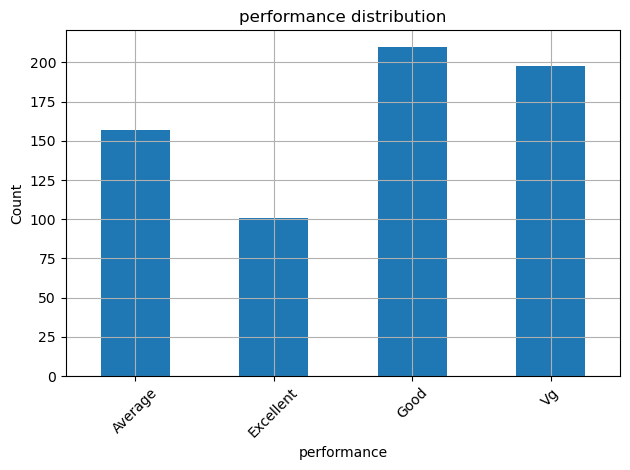

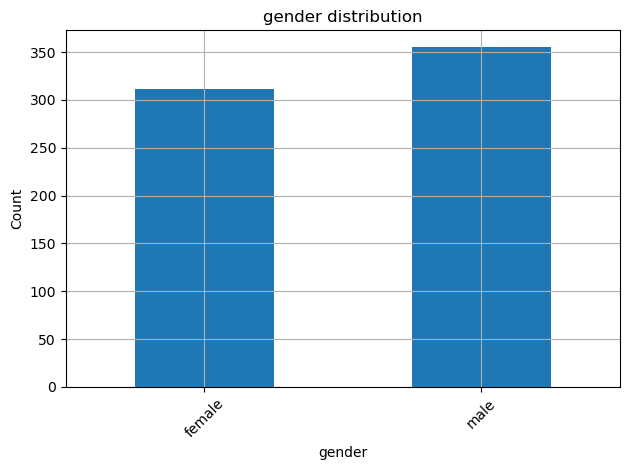

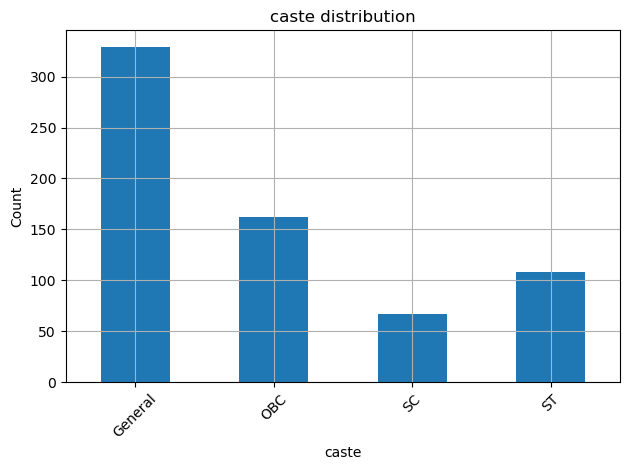

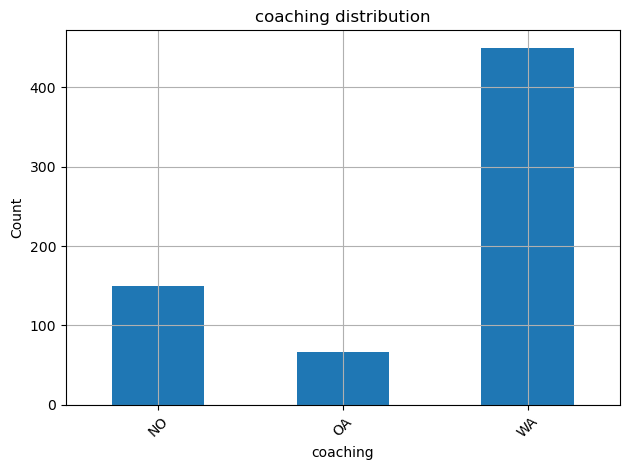

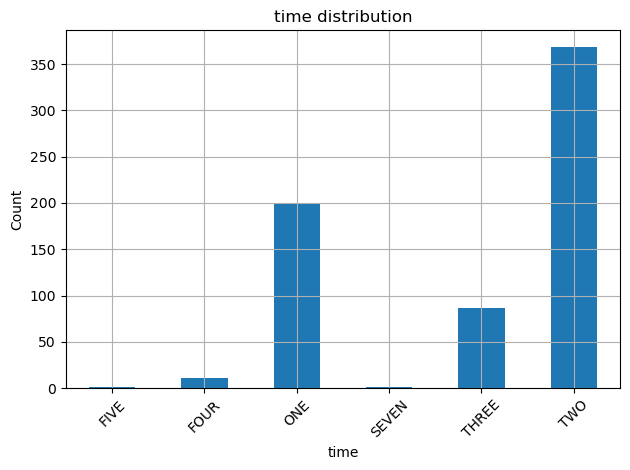

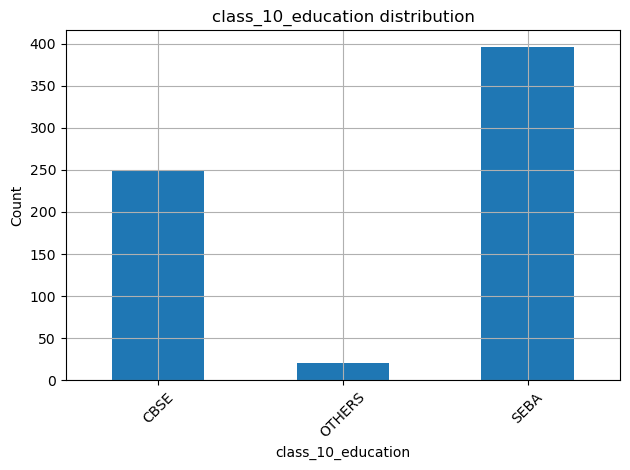

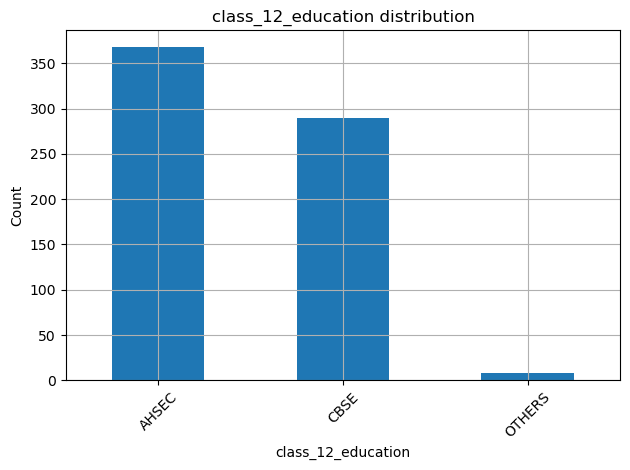

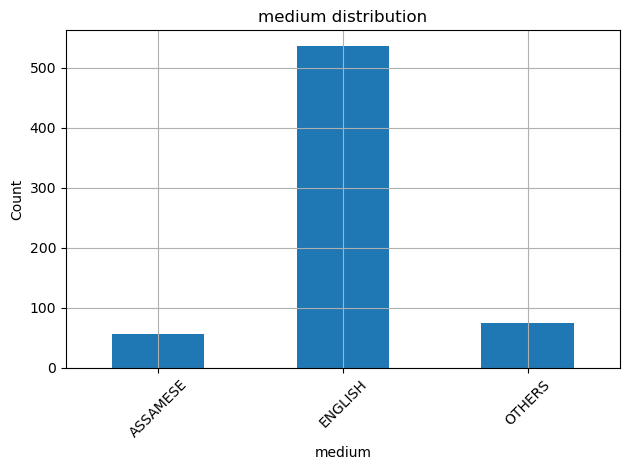

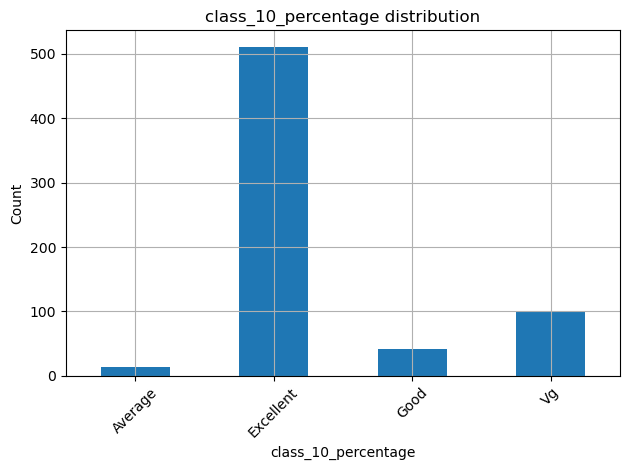

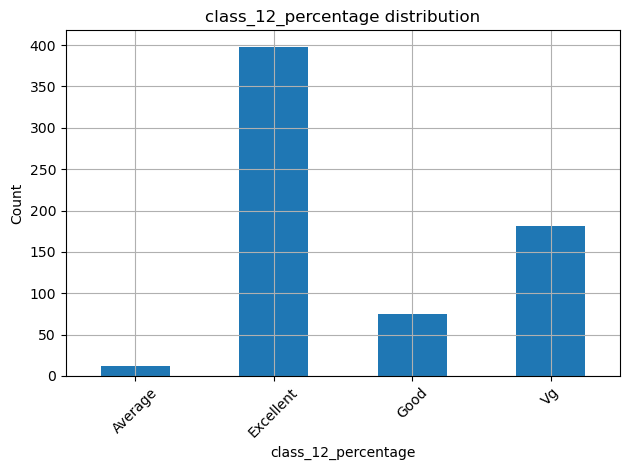

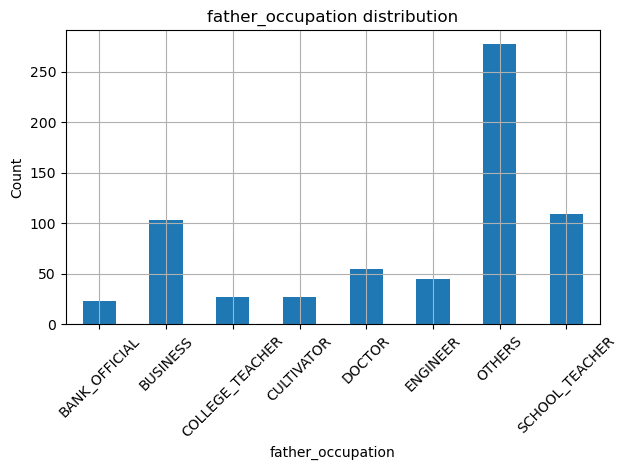

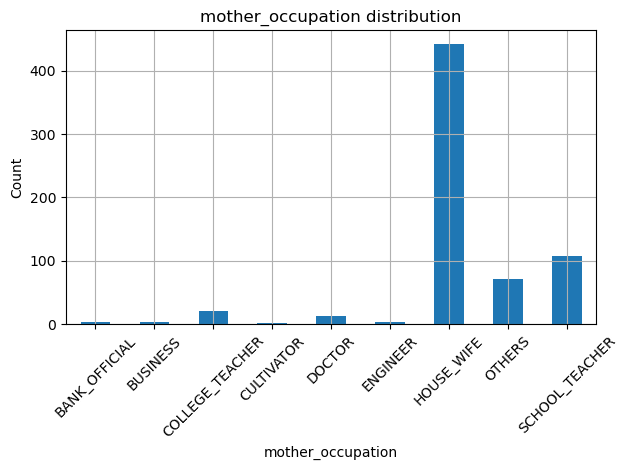

In [71]:
for col in df.columns:
    counts = df[col].value_counts()
    counts = counts.sort_index()

    counts.plot.bar(rot=45, grid=True)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f'{col} distribution')
    plt.tight_layout()
    plt.show()

### Look for Relationships and Correlations

Here we find the conditional distributions for every value of every input feature.
The conditional distribution is the fraction of a group that falls into a certain outcome class.
For example, in row 1: 24.7% of females had Average performance. 11.9% were in Excellent, 32.2% in Good, and 31.2% Vg (Very good). Some features (caste) are associated with big shifts in performance.

In [72]:
target = "performance"
features = [c for c in df.columns if c != target]

for c in features:
    print("\n==", c, "==")
    print(pd.crosstab(df[c], df[target], normalize="index"))


== gender ==
performance   Average  Excellent      Good        Vg
gender                                              
female       0.247588   0.118971  0.321543  0.311897
male         0.225352   0.180282  0.309859  0.284507

== caste ==
performance   Average  Excellent      Good        Vg
caste                                               
General      0.000000   0.252280  0.337386  0.410334
OBC          0.154321   0.092593  0.450617  0.302469
SC           0.462687   0.044776  0.313433  0.179104
ST           0.935185   0.000000  0.046296  0.018519

== coaching ==
performance   Average  Excellent      Good        Vg
coaching                                            
NO           0.266667   0.133333  0.346667  0.253333
OA           0.134328   0.358209  0.298507  0.208955
WA           0.240535   0.126949  0.307350  0.325167

== time ==
performance   Average  Excellent      Good        Vg
time                                                
FIVE         0.000000   0.000000  1.000000  

### Clean Data

The feature 'time' has two classes with a single record each, producing misleading results in the conditional distributions. It's also unclear what the feature actually records, and the dataset's publisher provides no description of the feature. For all these reasons, we choose to drop this feature.

In [73]:
X_train = X_train.drop(columns=['time'])
X_test = X_test.drop(columns=['time'])
df = df.drop(columns=['time'])

df.to_csv("../data/processed/CEE_DATA.csv", index=False)

## Feature Transformation

### Encode the Target Variable

In [74]:
target_mapping = {'Average': 0, 'Good': 1, 'Vg': 2, 'Excellent': 3}
y_train_mapped = y_train.map(target_mapping)

## Baseline Models

### Define the Preprocessing Pipeline

In [75]:
percentage_order = ['Average', 'Good', 'Vg', 'Excellent']

preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[percentage_order, percentage_order]),
         ['class_10_percentage', 'class_12_percentage']),
        
        ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         ['gender', 'caste', 'coaching', 'medium', 'father_occupation', 'mother_occupation', 'class_10_education', 'class_12_education'])
    ])

### Build Baseline Model Pipelines

In [76]:
knn_pipe = Pipeline([
    ('prep', preprocessor),
    ('select', SelectKBest(score_func=chi2, k=15)),
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

log_pipe = Pipeline([
    ('prep', preprocessor),
    ('select', SelectKBest(score_func=chi2, k=15)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

gnb_pipe = Pipeline([
    ('prep', preprocessor),
    ('select', SelectKBest(score_func=chi2, k=15)),
    ('model', GaussianNB())
])

### Initial Evaluation via Cross-Validation

Logistic Regression performed best at 52% accuracy (versus 25% for random chance).

In [77]:
models = [('kNN', knn_pipe), ('Logistic Regression', log_pipe), ('Gaussian NB', gnb_pipe)]

for name, pipeline in models:
    results = cross_validate(pipeline, X_train, y_train_mapped, cv=10, scoring='accuracy')

    mean_acc = results['test_score'].mean()
    std_acc = results['test_score'].std()

    print(f"{name}: Mean Accuracy: {mean_acc:.4f}, (+/- {std_acc:.4f})")

kNN: Mean Accuracy: 0.4624, (+/- 0.0604)
Logistic Regression: Mean Accuracy: 0.5224, (+/- 0.0761)
Gaussian NB: Mean Accuracy: 0.3384, (+/- 0.0147)


## Milestone 3

### Hyperparameter Tuning

We test 52 versions of our best baseline model. Our best model is logistic regression with a regularization strength of 1 and dropping all but the 13 best features.

In [78]:
param_grid = [
    {
        'select__k': [5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29],
        'model__C': [0.01, 0.1, 1, 10]
    }
]

grid_search = GridSearchCV(log_pipe, param_grid, cv=10, scoring='accuracy', verbose=1)

grid_search.fit(X_train, y_train_mapped)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Fitting 10 folds for each of 52 candidates, totalling 520 fits
Best parameters: {'model__C': 1, 'select__k': 13}
Best CV accuracy: 0.5374


### Final Evaluation on the Test Set

In [79]:
y_test_mapped = y_test.map(target_mapping)

final_model = grid_search.best_estimator_

final_predictions = final_model.predict(X_test)

final_accuracy = accuracy_score(y_test_mapped, final_predictions)
print(f"Final test set accuracy: {final_accuracy:.4f}")

Final test set accuracy: 0.5373


### Confusion Matrix

The confusion matrix shows that while our model does misclassify ~46% of instances, it usually misclassifies them into adjacent categories - for example, it didn't misclassify any Excellent instances as Average.

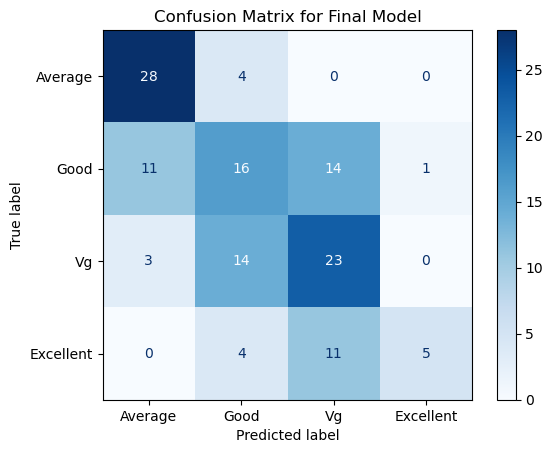

In [80]:
cm = confusion_matrix(y_test_mapped, final_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_mapping.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Final Model")
plt.show()

### Classification Report

The model handles average well. It correctly identifies 88% of average students. This is partly because the model is over-predicting Average. Excellent has the opposite problem - the model only catches 1 in 4 Excellent students. Good is the weakest class - both precision and recall are low.

In [ ]:
print("Classification Report: ")
print(classification_report(y_test_mapped, final_predictions, target_names=target_mapping.keys()))

Classification Report: 
              precision    recall  f1-score   support

     Average       0.67      0.88      0.76        32
        Good       0.42      0.38      0.40        42
          Vg       0.48      0.57      0.52        40
   Excellent       0.83      0.25      0.38        20

    accuracy                           0.54       134
   macro avg       0.60      0.52      0.52       134
weighted avg       0.56      0.54      0.52       134


Top features for predicting 'Excellent':
nom__caste_General: 0.7317
nom__coaching_OA: 0.3323
nom__medium_OTHERS: 0.2627
nom__father_occupation_COLLEGE_TEACHER: 0.1972
nom__mother_occupation_COLLEGE_TEACHER: 0.1937


### Feature Importance

The strongest predictor of excellent performance is being from the General caste category. The next strongest predictors are private coaching, studying in a language other than English or Assamese, and having a college teacher for a parent.

In [ ]:
feature_mask = final_model.named_steps['select'].get_support()
all_feature_names = final_model.named_steps['prep'].get_feature_names_out()
feature_names = all_feature_names[feature_mask]

excellent_coefs = final_model.named_steps['model'].coef_[3]

feature_importance = sorted(zip(excellent_coefs, feature_names), reverse=True)
print("\nTop features for predicting 'Excellent':")
for score, name in feature_importance[:5]:
    print(f"{name}: {score:.4f}")

### Save the Final Model

In [ ]:
import joblib

joblib.dump(final_model, 'final_model.joblib')
print("Model saved as final_model.joblib")